### STEP:1 __Data Quality Assessment and Dataset Cleaning

### 1 — Import Libraries

Imports required libraries for:

data analysis
cleaning
preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2 — Load Combined Dataset

Loads the combined stock dataset.

In [56]:
combined_stock_data = pd.read_csv(
    "combined_stock_dataset.csv"
)

### 3 — Display Sample Records

Displays the first 5 rows of the dataset to inspect structure and formatting.

In [57]:
combined_stock_data.head()

,Date,Close,High,Low,Open,Volume,Company
0,01-01-2015,70.761368,71.129618,69.403909,70.097080,3946806,Adani
1,02-01-2015,71.107956,71.772244,70.761364,70.949104,6565229,Adani
2,05-01-2015,72.284920,73.151383,70.862473,70.920237,9404837,Adani
3,06-01-2015,71.736130,74.790421,69.923775,71.570061,18412441,Adani
4,07-01-2015,71.100739,73.295785,69.606087,72.205482,10863352,Adani


### 4 — Check Dataset Information

Displays:

total rows
total columns
datatypes
non-null values

In [58]:
combined_stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7401 entries, 0 to 7400
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     7401 non-null   object 
 1   Close    7401 non-null   float64
 2   High     7401 non-null   float64
 3   Low      7401 non-null   float64
 4   Open     7401 non-null   float64
 5   Volume   7401 non-null   int64  
 6   Company  7401 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 404.9+ KB


### 5 — Check Missing Values

Checks missing/null values in each column

In [59]:
combined_stock_data.isnull().sum()

Date       0
Close      0
High       0
Low        0
Open       0
Volume     0
Company    0
dtype: int64

### 6 — Check Duplicate Rows

Checks duplicate records in the dataset.

In [60]:
combined_stock_data.duplicated().sum()

np.int64(0)

### 7 — Check Current Datatypes

Displays datatype of each column.

In [61]:
combined_stock_data.dtypes

Date        object
Close      float64
High       float64
Low        float64
Open       float64
Volume       int64
Company     object
dtype: object

### 8 — Convert Date Column

Converts the Date column from text format (object) into datetime format.

This is important for:

time-series analysis
visualization
forecasting

In [62]:
combined_stock_data['Date'] = pd.to_datetime(
    combined_stock_data['Date'],
    errors='coerce'
)

In [63]:
combined_stock_data.dtypes

Date       datetime64[ns]
Close             float64
High              float64
Low               float64
Open              float64
Volume              int64
Company            object
dtype: object

### 9 — Convert Numeric Columns

Converts stock price and volume columns into numeric datatype.

In [64]:
numeric_cols = ['Open','High','Low','Close','Volume']
for col in numeric_cols:
    combined_stock_data[col] = pd.to_numeric(combined_stock_data[col],errors='coerce')

In [65]:
combined_stock_data.dtypes

Date       datetime64[ns]
Close             float64
High              float64
Low               float64
Open              float64
Volume              int64
Company            object
dtype: object

### 10 — Check Duplicate Rows

Displays total duplicate rows in the dataset.

In [66]:
combined_stock_data.duplicated().sum()

np.int64(0)

### 11 — check missing date rows 

In [67]:
combined_stock_data[
    combined_stock_data['Date'].isnull()
]

,Date,Close,High,Low,Open,Volume,Company
8,NaT,71.728928,74.920406,71.476206,74.797661,7711411,Adani
9,NaT,70.956314,72.017734,70.183715,71.988852,6088603,Adani
10,NaT,72.335434,72.905859,70.183711,72.205465,8490702,Adani
11,NaT,72.248810,73.144162,71.107967,71.988871,7528008,Adani
12,NaT,73.115265,73.938404,72.227137,72.494293,7947209,Adani
...,...,...,...,...,...,...,...
7396,NaT,3966.891846,4003.433378,3946.770089,3946.770089,1181886,TCS
7397,NaT,3957.020996,3986.301772,3932.390868,3966.891863,1208464,TCS
7398,NaT,3952.987061,3968.268157,3936.282268,3951.231076,858100,TCS
7399,NaT,3947.244629,3985.684423,3902.825497,3939.841595,1527169,TCS


### 12 — Remove rows where Date is missing.


In [68]:
combined_stock_data = combined_stock_data.dropna(
    subset=['Date']
)

### 13 — Reset Index

Resets row numbering after cleaning.

In [69]:
combined_stock_data.reset_index(drop=True,inplace=True)

### 14 — Display Final Cleaned Dataset

Displays first 5 rows of cleaned dataset.

In [70]:
combined_stock_data.head()

,Date,Close,High,Low,Open,Volume,Company
0,2015-01-01,70.761368,71.129618,69.403909,70.097080,3946806,Adani
1,2015-02-01,71.107956,71.772244,70.761364,70.949104,6565229,Adani
2,2015-05-01,72.284920,73.151383,70.862473,70.920237,9404837,Adani
3,2015-06-01,71.736130,74.790421,69.923775,71.570061,18412441,Adani
4,2015-07-01,71.100739,73.295785,69.606087,72.205482,10863352,Adani


### 15 — Save Final Cleaned Dataset

Saves the final cleaned dataset.

In [71]:
combined_stock_data.to_csv("combined_stock_dataset_cleaned.csv",index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


 ### STEP:2 __ feature engineering 

### 2.1 — Display Dataset Information
What this cell does:-
Displays first 5 rows
Checks dataset structure
Verifies column names and data types

In [72]:
print(combined_stock_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2928 entries, 0 to 2927
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2928 non-null   datetime64[ns]
 1   Close    2928 non-null   float64       
 2   High     2928 non-null   float64       
 3   Low      2928 non-null   float64       
 4   Open     2928 non-null   float64       
 5   Volume   2928 non-null   int64         
 6   Company  2928 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 160.3+ KB
None


### 2.2 — Sort Dataset
What this cell does:-
Sorts data company-wise and date-wise
Resets index after sorting

In [73]:
combined_stock_data = combined_stock_data.sort_values(
    by=['Company', 'Date']
)
combined_stock_data = combined_stock_data.reset_index(drop=True)
combined_stock_data.head()

,Date,Close,High,Low,Open,Volume,Company
0,2015-01-01,70.761368,71.129618,69.403909,70.097080,3946806,Adani
1,2015-01-04,88.437271,88.928267,87.079806,87.917393,5663060,Adani
2,2015-01-06,91.419357,104.221384,90.588994,102.387364,71545880,Adani
3,2015-01-07,47.052086,47.745163,46.744051,46.872399,8195635,Adani
4,2015-01-09,38.032627,39.406029,37.161047,39.089088,6376473,Adani


### 2.3 — Daily Price Change Feature
Creates feature showing stock gain/loss during the day

In [74]:
combined_stock_data['Daily_Price_Change'] = (
    combined_stock_data['Close'] -
    combined_stock_data['Open']
)
combined_stock_data[
    ['Open', 'Close', 'Daily_Price_Change']
].head()

,Open,Close,Daily_Price_Change
0,70.097080,70.761368,0.664288
1,87.917393,88.437271,0.519878
2,102.387364,91.419357,-10.968007
3,46.872399,47.052086,0.179686
4,39.089088,38.032627,-1.056461


### 2.4 — Daily Return Percentage Feature
What this cell does:-
Calculates daily percentage return

In [75]:
combined_stock_data['Daily_Return_Percentage'] = (
    (
        combined_stock_data['Close'] -
        combined_stock_data['Open']
    )
    / combined_stock_data['Open']
) * 100
combined_stock_data[
    ['Open', 'Close', 'Daily_Return_Percentage']
].head()

,Open,Close,Daily_Return_Percentage
0,70.097080,70.761368,0.947669
1,87.917393,88.437271,0.591325
2,102.387364,91.419357,-10.712266
3,46.872399,47.052086,0.383352
4,39.089088,38.032627,-2.702701


### 2.5 — Price Volatility Feature
What this cell does:-
Measures daily stock fluctuation

In [76]:
combined_stock_data['Price_Volatility'] = (
    combined_stock_data['High'] -
    combined_stock_data['Low']
)
combined_stock_data[
    ['High', 'Low', 'Price_Volatility']
].head()

,High,Low,Price_Volatility
0,71.129618,69.403909,1.725709
1,88.928267,87.079806,1.848461
2,104.221384,90.588994,13.632391
3,47.745163,46.744051,1.001112
4,39.406029,37.161047,2.244982


### 2.6 — High Low Percentage Feature
What this cell does:-
Calculates percentage variation between High and Low

In [77]:
combined_stock_data['High_Low_Percentage'] = (
    (
        combined_stock_data['High'] -
        combined_stock_data['Low']
    )/combined_stock_data['Low']
) * 100
combined_stock_data[
    ['High', 'Low', 'High_Low_Percentage']
].head()

,High,Low,High_Low_Percentage
0,71.129618,69.403909,2.486472
1,88.928267,87.079806,2.122721
2,104.221384,90.588994,15.048617
3,47.745163,46.744051,2.141688
4,39.406029,37.161047,6.041223


### 2.7 — Rolling Standard Deviation
What this cell does:-
Measures rolling volatility

In [78]:
combined_stock_data['Rolling_STD_7'] = (combined_stock_data
    .groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=7).std()
    )
)
combined_stock_data[
    ['Close', 'Rolling_STD_7']
].head(10)

,Close,Rolling_STD_7
0,70.761368,NaN
1,88.437271,NaN
2,91.419357,NaN
3,47.052086,NaN
4,38.032627,NaN
5,42.549007,NaN
6,43.050823,22.925403
7,71.107956,22.952408
8,94.560295,24.284333
9,102.517342,26.822509


### 2.8 — Previous Day Closing Price
What this cell does:-
Creates previous day close feature

In [79]:
combined_stock_data['Previous_Close'] = (combined_stock_data.groupby('Company')['Close'].shift(1)
)
combined_stock_data[
    ['Close', 'Previous_Close']
].head()

,Close,Previous_Close
0,70.761368,NaN
1,88.437271,70.761368
2,91.419357,88.437271
3,47.052086,91.419357
4,38.032627,47.052086


### 2.9— 3-Day Lag Feature
What this cell does:-
Stores closing price from previous 3 days

In [80]:
combined_stock_data['Close_Lag_3'] = (
    combined_stock_data
    .groupby('Company')['Close']
    .shift(3)
)
combined_stock_data[
    ['Close', 'Close_Lag_3']
].head()

,Close,Close_Lag_3
0,70.761368,NaN
1,88.437271,NaN
2,91.419357,NaN
3,47.052086,70.761368
4,38.032627,88.437271


### 2.10 — Day of Week Feature
What this cell does:-

Extracts weekday names

In [81]:
combined_stock_data['Day_of_Week'] = (combined_stock_data['Date'].dt.day_name()
)
combined_stock_data[
    ['Date', 'Day_of_Week']
].head()

,Date,Day_of_Week
0,2015-01-01,Thursday
1,2015-01-04,Sunday
2,2015-01-06,Tuesday
3,2015-01-07,Wednesday
4,2015-01-09,Friday


### 2.11— Month Feature
What this cell does:-
Extracts month names

In [82]:
combined_stock_data['Month'] = (
    combined_stock_data['Date'].dt.month_name()
)

combined_stock_data[
    ['Date', 'Month']
].head()

,Date,Month
0,2015-01-01,January
1,2015-01-04,January
2,2015-01-06,January
3,2015-01-07,January
4,2015-01-09,January


In [83]:
combined_stock_data['Month'] = (
    combined_stock_data['Date'].dt.month_name()
)

combined_stock_data[
    ['Date', 'Month']
].tail()

,Date,Month
2923,2024-12-07,December
2924,2024-12-08,December
2925,2024-12-09,December
2926,2024-12-11,December
2927,2024-12-12,December


### 2.14 — Price Range Ratio
What this cell does:-
Measures relative price movement

In [84]:
combined_stock_data['Price_Range_Ratio'] = (
    (
        combined_stock_data['High'] -
        combined_stock_data['Low']
    )/combined_stock_data['Close']
)
combined_stock_data[
    ['High', 'Low', 'Close', 'Price_Range_Ratio']
].head()

,High,Low,Close,Price_Range_Ratio
0,71.129618,69.403909,70.761368,0.024388
1,88.928267,87.079806,88.437271,0.020901
2,104.221384,90.588994,91.419357,0.149119
3,47.745163,46.744051,47.052086,0.021277
4,39.406029,37.161047,38.032627,0.059028


### 2.15 — Closing Price Difference
What this cell does:-
Calculates difference between current and previous closing price

In [85]:
combined_stock_data['Closing_Price_Difference'] = (
    combined_stock_data
    .groupby('Company')['Close']
    .diff()
)
combined_stock_data[
    ['Close', 'Closing_Price_Difference']
].head()

,Close,Closing_Price_Difference
0,70.761368,NaN
1,88.437271,17.675903
2,91.419357,2.982086
3,47.052086,-44.367271
4,38.032627,-9.019459


### 2.16 — Check Missing Values
What this cell does:-
Finds null values generated from rolling and lag operations

In [86]:
combined_stock_data.isnull().sum()

Date                         0
Close                        0
High                         0
Low                          0
Open                         0
Volume                       0
Company                      0
Daily_Price_Change           0
Daily_Return_Percentage      0
Price_Volatility             0
High_Low_Percentage          0
Rolling_STD_7               18
Previous_Close               3
Close_Lag_3                  9
Day_of_Week                  0
Month                        0
Price_Range_Ratio            0
Closing_Price_Difference     3
dtype: int64

### 2.16 — Remove Missing Values
What this cell does
Removes rows containing null values

In [87]:
combined_stock_data = combined_stock_data.dropna()
combined_stock_data.isnull().sum()

Date                        0
Close                       0
High                        0
Low                         0
Open                        0
Volume                      0
Company                     0
Daily_Price_Change          0
Daily_Return_Percentage     0
Price_Volatility            0
High_Low_Percentage         0
Rolling_STD_7               0
Previous_Close              0
Close_Lag_3                 0
Day_of_Week                 0
Month                       0
Price_Range_Ratio           0
Closing_Price_Difference    0
dtype: int64

### 2.17 — Final Dataset Shape
What this cell does:-
Displays final rows and columns count

In [88]:
combined_stock_data.shape

(2910, 18)

### 2.18 —— rounding to keep only 4 digits after the decimal point.

In [89]:
combined_stock_data = combined_stock_data.round(4)

In [91]:
combined_stock_data.head()

,Date,Close,High,Low,Open,Volume,Company,Daily_Price_Change,Daily_Return_Percentage,Price_Volatility,High_Low_Percentage,Rolling_STD_7,Previous_Close,Close_Lag_3,Day_of_Week,Month,Price_Range_Ratio,Closing_Price_Difference
6,2015-01-12,43.0508,43.7375,42.7075,43.7111,2357904,Adani,-0.6603,-1.5106,1.0301,2.4119,22.9254,42.5490,47.0521,Monday,January,0.0239,0.5018
7,2015-02-01,71.1080,71.7722,70.7614,70.9491,6565229,Adani,0.1589,0.2239,1.0109,1.4286,22.9524,43.0508,38.0326,Sunday,February,0.0142,28.0571
8,2015-02-02,94.5603,95.6867,92.2930,94.0115,41701833,Adani,0.5488,0.5837,3.3937,3.6770,24.2843,71.1080,42.5490,Monday,February,0.0359,23.4523
9,2015-02-03,102.5173,103.3982,99.6436,101.3765,8781363,Adani,1.1408,1.1254,3.7547,3.7681,26.8225,94.5603,43.0508,Tuesday,February,0.0366,7.9570
10,2015-02-06,91.9898,94.3653,89.7514,92.1342,112566102,Adani,-0.1444,-0.1567,4.6139,5.1408,27.8137,102.5173,71.1080,Friday,February,0.0502,-10.5276


### Save Updated Dataset

In [93]:
combined_stock_data.to_csv(
    "feature_engineered_stock_data.csv",
    index=False
)
print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


### STEP:3 Exploratory Data Analysis (EDA) of Stock Market Dataset
Analyzing Historical Trends, Market Behavior, Volatility, and Stock Performance of Adani, Reliance, and TCS

use cases :

1. Historical Stock Price Movement Analysis
2. Company-wise Stock Performance Comparison
3. Market Trend and Direction Analysis
4. Time Series Forecasting
5. High-Low Price Range Analysis
6. Risk Analysis Based on Price Fluctuation


### 3.1 — Import Required Libraries
What this cell does:-
Imports all libraries required for EDA and visualization.

In [94]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### 3.2 — Load Dataset
What this cell does:-
Loads your feature engineered stock dataset.

In [95]:
feature_engineered_stock_data = pd.read_csv(
    "feature_engineered_stock_data.csv"
)

### 3.3 — Display First Rows
What this cell does:-
Displays first 5 rows of dataset.

In [96]:
feature_engineered_stock_data.head()

,Date,Close,High,Low,Open,Volume,Company,Daily_Price_Change,Daily_Return_Percentage,Price_Volatility,High_Low_Percentage,Rolling_STD_7,Previous_Close,Close_Lag_3,Day_of_Week,Month,Price_Range_Ratio,Closing_Price_Difference
0,2015-01-12,43.0508,43.7375,42.7075,43.7111,2357904,Adani,-0.6603,-1.5106,1.0301,2.4119,22.9254,42.5490,47.0521,Monday,January,0.0239,0.5018
1,2015-02-01,71.1080,71.7722,70.7614,70.9491,6565229,Adani,0.1589,0.2239,1.0109,1.4286,22.9524,43.0508,38.0326,Sunday,February,0.0142,28.0571
2,2015-02-02,94.5603,95.6867,92.2930,94.0115,41701833,Adani,0.5488,0.5837,3.3937,3.6770,24.2843,71.1080,42.5490,Monday,February,0.0359,23.4523
3,2015-02-03,102.5173,103.3982,99.6436,101.3765,8781363,Adani,1.1408,1.1254,3.7547,3.7681,26.8225,94.5603,43.0508,Tuesday,February,0.0366,7.9570
4,2015-02-06,91.9898,94.3653,89.7514,92.1342,112566102,Adani,-0.1444,-0.1567,4.6139,5.1408,27.8137,102.5173,71.1080,Friday,February,0.0502,-10.5276


### 3.4 — Dataset Shape
What this cell does:-
Shows total rows and columns.

In [97]:
feature_engineered_stock_data.shape

(2910, 18)

### 3.5 — Dataset Information
What this cell does;-

Displays column names and data types.

In [46]:
feature_engineered_stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2841 entries, 0 to 2840
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      2841 non-null   object 
 1   Close                     2841 non-null   float64
 2   High                      2841 non-null   float64
 3   Low                       2841 non-null   float64
 4   Open                      2841 non-null   float64
 5   Volume                    2841 non-null   int64  
 6   Company                   2841 non-null   object 
 7   Daily_Price_Change        2841 non-null   float64
 8   Daily_Return_Percentage   2841 non-null   float64
 9   Price_Volatility          2841 non-null   float64
 10  High_Low_Percentage       2841 non-null   float64
 11  Moving_Average_7          2841 non-null   float64
 12  Moving_Average_30         2841 non-null   float64
 13  Rolling_STD_7             2841 non-null   float64
 14  Previous

### 3.6 — Company-wise Record Count
What this cell does:0-
Counts records for each company.

In [48]:
feature_engineered_stock_data['Company'].value_counts()

Company
Adani       947
Reliance    947
TCS         947
Name: count, dtype: int64

### 3.7 — Historical Stock Price Movement Analysis
What this cell does:-
Shows stock closing price movement over time.

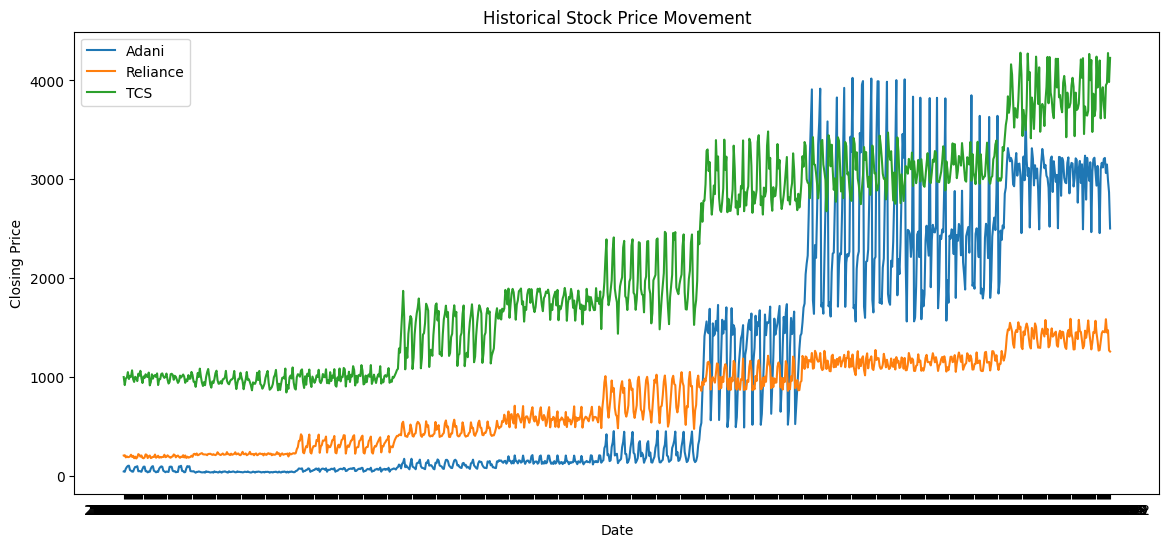

In [49]:
plt.figure(figsize=(14,6))
for company in feature_engineered_stock_data['Company'].unique():    
    company_data = feature_engineered_stock_data[
        feature_engineered_stock_data['Company'] == company
    ]
    
    plt.plot(
        company_data['Date'],
        company_data['Close'],
        label=company
    )
plt.title("Historical Stock Price Movement")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

### 3.8 — Company-wise Stock Performance Comparison
What this cell does:-
Compares average closing prices of companies.

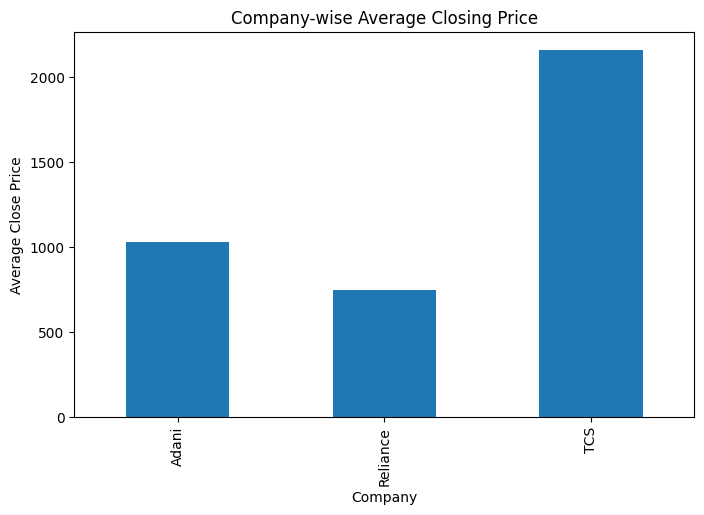

In [50]:
company_performance = (
    feature_engineered_stock_data
    .groupby('Company')['Close']
    .mean()
)
company_performance.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Company-wise Average Closing Price")
plt.ylabel("Average Close Price")
plt.show()

### 3.9 — Market Trend and Direction Analysis
What this cell does:-
Displays moving average trend.

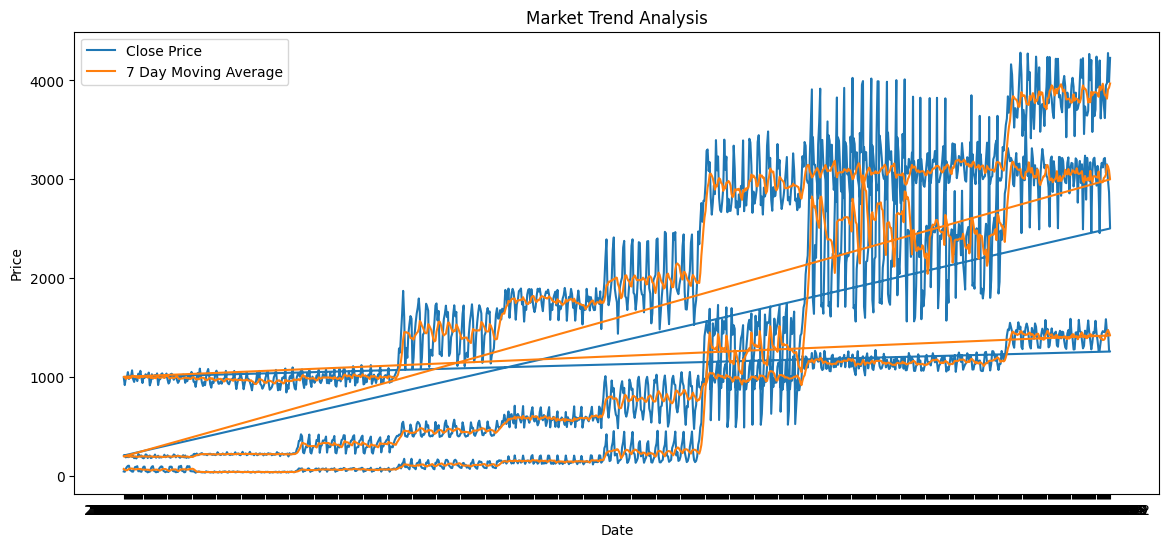

In [51]:
plt.figure(figsize=(14,6))
plt.plot(
    feature_engineered_stock_data['Date'],
    feature_engineered_stock_data['Close'],
    label='Close Price'
)
plt.plot(
    feature_engineered_stock_data['Date'],
    feature_engineered_stock_data['Moving_Average_7'],
    label='7 Day Moving Average'
)
plt.title("Market Trend Analysis")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

### 3.10 — Time-Series Trend Analysis
What this cell does:-
Displays time-based stock trend.

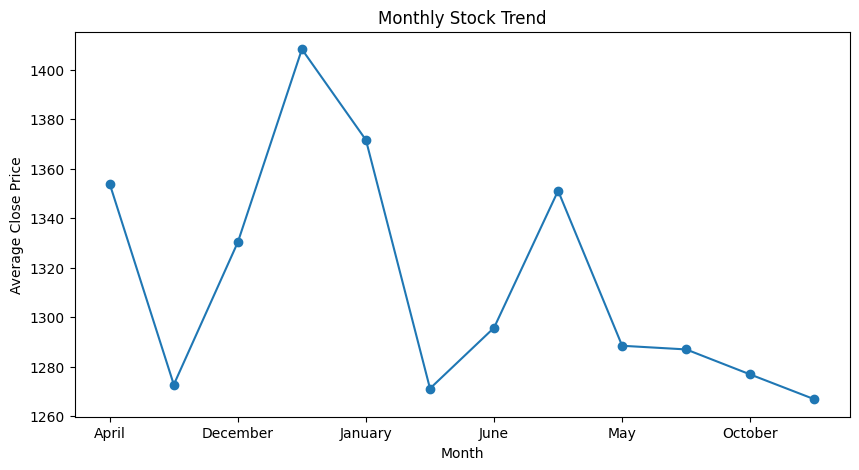

In [52]:
monthly_trend = (
    feature_engineered_stock_data
    .groupby('Month')['Close']
    .mean()
)
monthly_trend.plot(
    kind='line',
    figsize=(10,5),
    marker='o'
)
plt.title("Monthly Stock Trend")
plt.ylabel("Average Close Price")
plt.show()

### 3.11 — Risk Analysis Based on Price Fluctuation
What this cell does:-
Compares stock volatility.

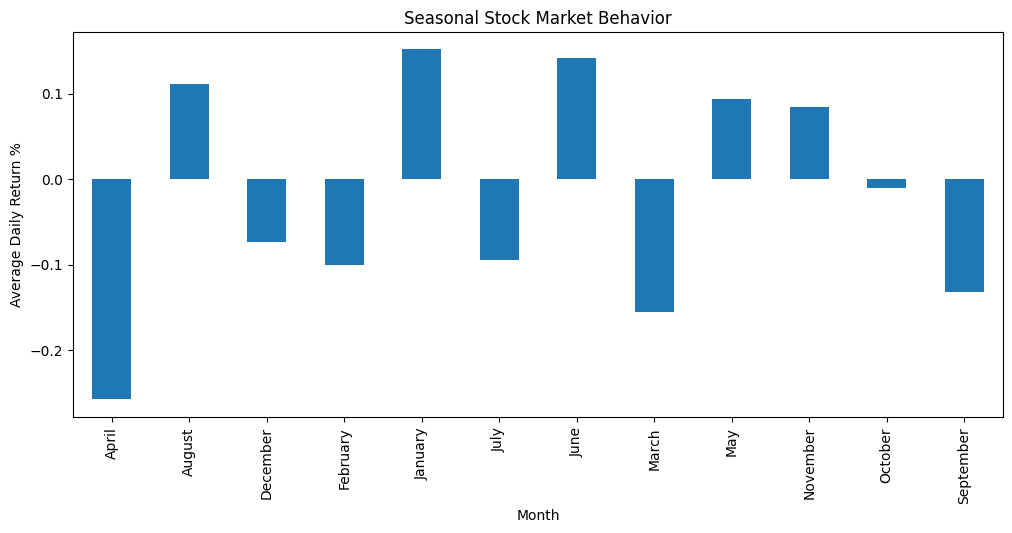

In [53]:
monthly_behavior = (
    feature_engineered_stock_data
    .groupby('Month')['Daily_Return_Percentage']
    .mean()
)

monthly_behavior.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Seasonal Stock Market Behavior")
plt.ylabel("Average Daily Return %")
plt.show()

### 3.12 — Risk Analysis Based on volatility

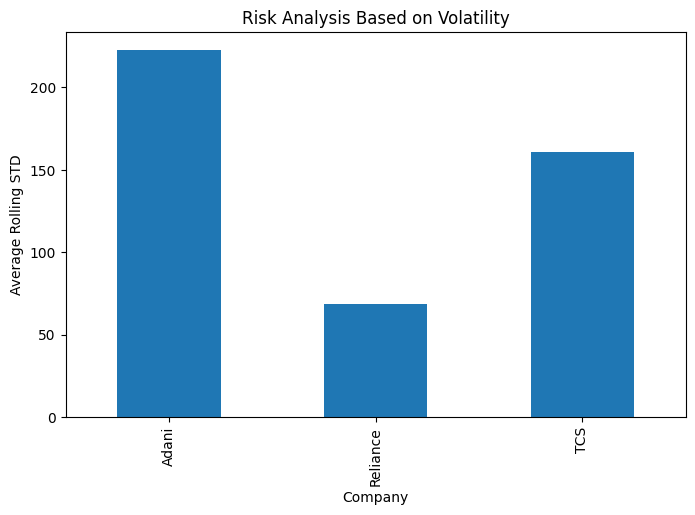

In [54]:
volatility = (
    feature_engineered_stock_data
    .groupby('Company')['Rolling_STD_7']
    .mean()
)

volatility.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Risk Analysis Based on Volatility")
plt.ylabel("Average Rolling STD")
plt.show()